<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_4_Leveraging_Influential_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Leveraging Influential CNN Architectures & Transfer Learning

# 1. Environment Setup

In [1]:
# Installing the required libraries
!pip install -q tensorflow tensorflow-datasets matplotlib

In [2]:
# Importing libraries
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# 2. Load and Prepare Dataset

In [3]:
# Loading the dataset
dataset, info = tfds.load('oxford_iiit_pet', with_info=True)

train_ds = dataset['train']
test_ds = dataset['test']

# Splitting train into train + validation
train_size = int(0.8 * info.splits['train'].num_examples)
val_size = int(0.2 * info.splits['train'].num_examples)

train_ds = train_ds.take(train_size)
val_ds = train_ds.skip(train_size)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.7PPZJ2_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.7PPZJ2_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


# 3. Visualize Sample Images

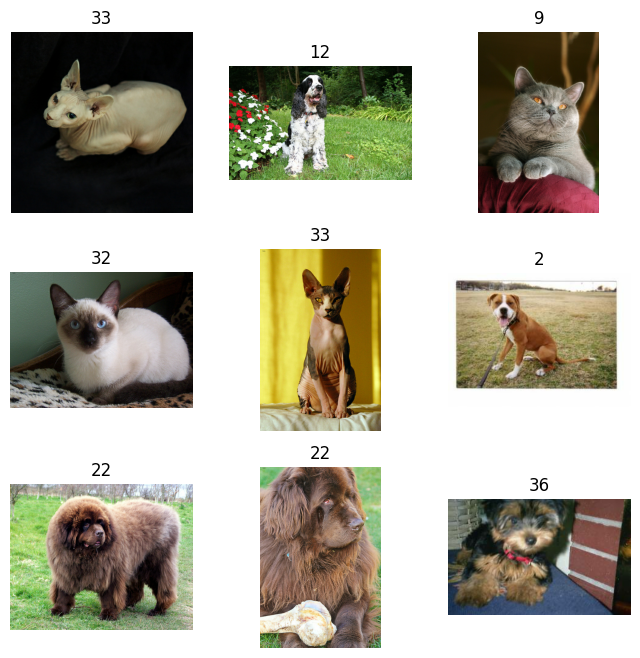

In [4]:
plt.figure(figsize=(8,8))
for i, sample in enumerate(train_ds.take(9)):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(sample['image'])
    plt.title(sample['label'].numpy())
    plt.axis('off')
plt.show()

# 4. Preprocessing Pipeline

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, label

train_ds = train_ds.map(lambda x: preprocess(x['image'], x['label'])).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x: preprocess(x['image'], x['label'])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x: preprocess(x['image'], x['label'])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# 5. Feature Extraction using VGG16

In [7]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(37, activation='softmax')(x)

model_vgg = models.Model(inputs=base_model.input, outputs=output)

model_vgg.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_vgg = model_vgg.fit(train_ds, validation_data=val_ds, epochs=1)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1547s 17s/step - accuracy: 0.0560 - loss: 3.5761


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


# 6. Fine-Tuning using ResNet50

In [10]:
base_model_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model_res.trainable = False

x = base_model_res.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(37, activation='softmax')(x)

model_res = models.Model(inputs=base_model_res.input, outputs=output)

model_res.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Initializing training
model_res.fit(train_ds, validation_data=val_ds, epochs=1)

# Unfreeze last layers
for layer in base_model_res.layers[-10:]:
    layer.trainable = True

model_res.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history_res = model_res.fit(train_ds, validation_data=val_ds, epochs=1)

92/92 ━━━━━━━━━━━━━━━━━━━━ 494s 5s/step - accuracy: 0.0296 - loss: 3.6819
92/92 ━━━━━━━━━━━━━━━━━━━━ 580s 6s/step - accuracy: 0.0302 - loss: 3.6041


# 7. Evaluate Models

In [ ]:
vgg_loss, vgg_acc = model_vgg.evaluate(test_ds)
res_loss, res_acc = model_res.evaluate(test_ds)

print("VGG16 Test Accuracy:", vgg_acc)
print("ResNet50 Test Accuracy:", res_acc)

  6/115 ━━━━━━━━━━━━━━━━━━━━ 30:04 17s/step - accuracy: 0.0760 - loss: 3.3494

# 8. Plot Training Performance

In [ ]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train','Val'])
    plt.show()

plot_history(history_vgg, "VGG16 Performance")
plot_history(history_res, "ResNet50 Performance")